In [1]:
print("Rainfall Prediction Project Started!")

Rainfall Prediction Project Started!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import openpyxl

print("openpyxl installed successfully!")
print("Version:", openpyxl.__version__)

openpyxl installed successfully!
Version: 3.1.5


In [5]:
df = pd.read_excel("india_weather_rainfall_data.xlsx", nrows=100000)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 15)


## 3. Dataset Overview
View the first 5 rows   df.head()
Check the dataset structure    df.info()
check column names    df.columns
check dataset dimensions       number of row  df.shape[0
                               number of col df.shape[1




In [6]:
df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date_of_record  100000 non-null  datetime64[us]
 1   month           100000 non-null  str           
 2   season          100000 non-null  str           
 3   station_name    100000 non-null  str           
 4   state           100000 non-null  str           
 5   district        100000 non-null  str           
 6   avg_temp        100000 non-null  float64       
 7   min_temp        96414 non-null   float64       
 8   max_temp        93500 non-null   float64       
 9   wind_speed      69508 non-null   float64       
 10  air_pressure    68025 non-null   float64       
 11  elevation       100000 non-null  int64         
 12  latitude        100000 non-null  float64       
 13  longitude       100000 non-null  float64       
 14  rainfall        74835 non-null   float64       


In [8]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='str')

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100000
Number of columns: 15


## 4. Missing Value Analysis

In [10]:
missing_values = df.isnull().sum()

print(missing_values)

date_of_record        0
month                 0
season                0
station_name          0
state                 0
district              0
avg_temp              0
min_temp           3586
max_temp           6500
wind_speed        30492
air_pressure      31975
elevation             0
latitude              0
longitude             0
rainfall          25165
dtype: int64


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

date_of_record     0.000
month              0.000
season             0.000
station_name       0.000
state              0.000
district           0.000
avg_temp           0.000
min_temp           3.586
max_temp           6.500
wind_speed        30.492
air_pressure      31.975
elevation          0.000
latitude           0.000
longitude          0.000
rainfall          25.165
dtype: float64


In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", duplicate_percentage, "%")

Duplicate percentage: 0.0 %


In [14]:
## 6. Categorical Data Analysis
print("Number of states:", df["state"].nunique())
print(df["state"].value_counts().head(15))

Number of states: 9
state
UP    21147
HP    16317
JK    15357
HR    13139
PB    11772
RJ    10525
DL     7388
CH     3339
AR     1016
Name: count, dtype: int64


In [15]:
print("Number of stations:", df["station_name"].nunique())
print(df["station_name"].value_counts().head(15))

Number of stations: 43
station_name
Srinagar                  7388
New Delhi / Palam         3694
New Delhi / Safdarjung    3694
Amritsar                  3693
Jammu                     3690
Dehradun                  3690
Patiala                   3688
Ambala                    3688
Bareilly                  3686
Hissar                    3680
Ganganagar                3672
Chandigarh / S?rajpur     3339
Churu                     3330
Mukteshwar Kumaon         3177
Shimla                    3133
Name: count, dtype: int64


In [16]:
print("Number of seasons:", df["season"].nunique())
print(df["season"].value_counts())

Number of seasons: 4
season
Winter          34321
Monsoon         24837
Summer          24079
Post-monsoon    16763
Name: count, dtype: int64


In [17]:
print("Number of months:", df["month"].nunique())
print(df["month"].value_counts())

Number of months: 12
month
January      9575
December     8593
October      8519
July         8422
August       8341
November     8244
March        8196
May          8168
September    8074
June         7988
February     7957
April        7923
Name: count, dtype: int64


In [18]:
## 7. Numerical Data Analysis
df.describe()

,date_of_record,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
count,100000,100000.000000,96414.000000,93500.000000,69508.000000,68025.000000,100000.000000,100000.000000,100000.000000,74835.000000
mean,2021-03-23 03:01:18.624000,21.320287,15.292460,28.032434,6.966870,1010.696003,655.802870,30.494938,76.720979,3.756674
min,2015-01-01 00:00:00,-10.400000,-18.500000,-5.600000,0.000000,978.800000,0.000000,28.000000,73.300000,0.000000
25%,2019-02-07 00:00:00,15.000000,8.700000,22.100000,4.600000,1004.800000,216.000000,29.016700,74.916700,0.000000
50%,2021-11-21 00:00:00,21.800000,15.400000,28.700000,6.400000,1011.500000,271.000000,30.333300,76.766700,0.000000
75%,2023-07-03 00:00:00,28.300000,22.800000,34.400000,8.700000,1016.400000,874.000000,31.633300,77.200000,2.000000
max,2025-02-10 00:00:00,42.200000,36.600000,50.800000,29.900000,1036.500000,2652.000000,34.083300,95.383300,460.500000
std,NaN,8.317456,8.409659,8.412292,3.278366,7.279481,726.621207,1.762485,2.467169,11.623609


In [19]:
df.dtypes

date_of_record    datetime64[us]
month                        str
season                       str
station_name                 str
state                        str
district                     str
avg_temp                 float64
min_temp                 float64
max_temp                 float64
wind_speed               float64
air_pressure             float64
elevation                  int64
latitude                 float64
longitude                float64
rainfall                 float64
dtype: object

In [20]:
## 8. Rainfall Analysis
df["rainfall"].describe()

count    74835.000000
mean         3.756674
std         11.623609
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        460.500000
Name: rainfall, dtype: float64

In [21]:
print("Zero rainfall:", (df["rainfall"] == 0).sum())
print("Rainfall > 0:", (df["rainfall"] > 0).sum())

Zero rainfall: 43538
Rainfall > 0: 31297


In [22]:
zero_rain = (df["rainfall"] == 0).sum()
rainy_days = (df["rainfall"] > 0).sum()

print("Zero rainfall percentage:", zero_rain / len(df) * 100)
print("Rainfall percentage:", rainy_days / len(df) * 100)

Zero rainfall percentage: 43.538
Rainfall percentage: 31.297000000000004


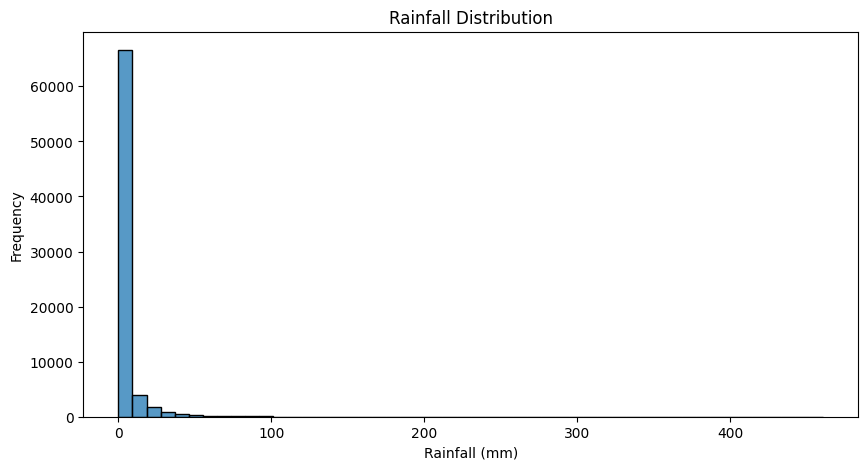

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(df["rainfall"].dropna(), bins=50)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

In [24]:
## 9. Rainfall Class Distribution
rainfall_status = df["rainfall"].dropna().apply(
    lambda x: "Rain" if x > 0 else "No Rain"
)

print(rainfall_status.value_counts())

rainfall
No Rain    43538
Rain       31297
Name: count, dtype: int64


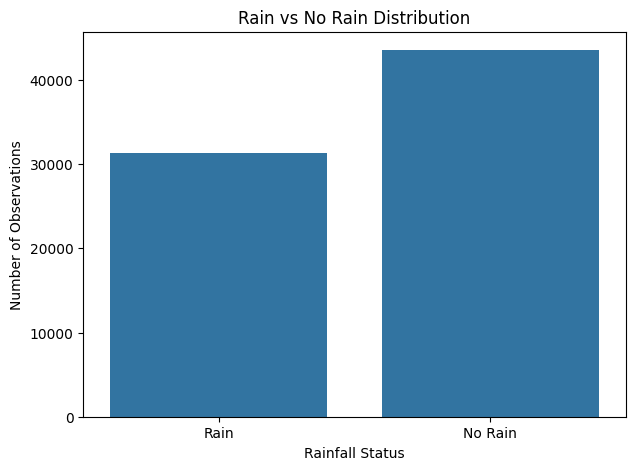

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(x=rainfall_status)

plt.title("Rain vs No Rain Distribution")
plt.xlabel("Rainfall Status")
plt.ylabel("Number of Observations")

plt.show()

## 10. Correlation Analysis

Correlation helps us understand the relationship between numerical
weather features.

We will examine whether variables such as temperature, wind speed,
air pressure, elevation, latitude, and longitude are related to rainfall.

In [26]:
numeric_columns = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "wind_speed",
    "air_pressure",
    "elevation",
    "latitude",
    "longitude",
    "rainfall"
]

correlation = df[numeric_columns].corr()

correlation

,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
avg_temp,1.000000,0.955788,0.957003,0.315768,-0.832738,-0.468320,-0.354462,0.021788,0.029449
min_temp,0.955788,1.000000,0.875527,0.332660,-0.864464,-0.409615,-0.364457,0.053505,0.095739
max_temp,0.957003,0.875527,1.000000,0.315739,-0.767753,-0.507154,-0.359431,-0.030134,-0.036393
wind_speed,0.315768,0.332660,0.315739,1.000000,-0.308414,-0.237635,-0.328273,0.009103,0.001172
air_pressure,-0.832738,-0.864464,-0.767753,-0.308414,1.000000,0.245459,0.312042,-0.090015,-0.126891
elevation,-0.468320,-0.409615,-0.507154,-0.237635,0.245459,1.000000,0.447404,-0.014938,0.033466
latitude,-0.354462,-0.364457,-0.359431,-0.328273,0.312042,0.447404,1.000000,-0.364775,0.011304
longitude,0.021788,0.053505,-0.030134,0.009103,-0.090015,-0.014938,-0.364775,1.000000,0.119250
rainfall,0.029449,0.095739,-0.036393,0.001172,-0.126891,0.033466,0.011304,0.119250,1.000000


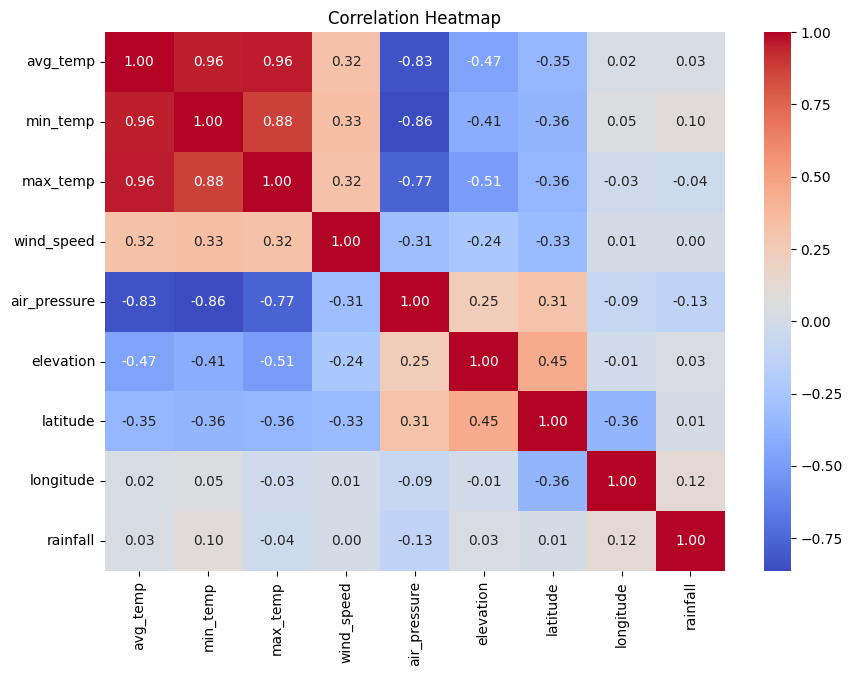

In [27]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## 11. Rainfall by Season

We analyze rainfall across different seasons to understand
seasonal patterns in the dataset.
1. Average rainfall by season
2. 2. Visualize it

In [28]:
season_rainfall = df.groupby("season")["rainfall"].mean()

print(season_rainfall)

season
Monsoon         7.928603
Post-monsoon    1.448751
Summer          2.826867
Winter          2.051969
Name: rainfall, dtype: float64


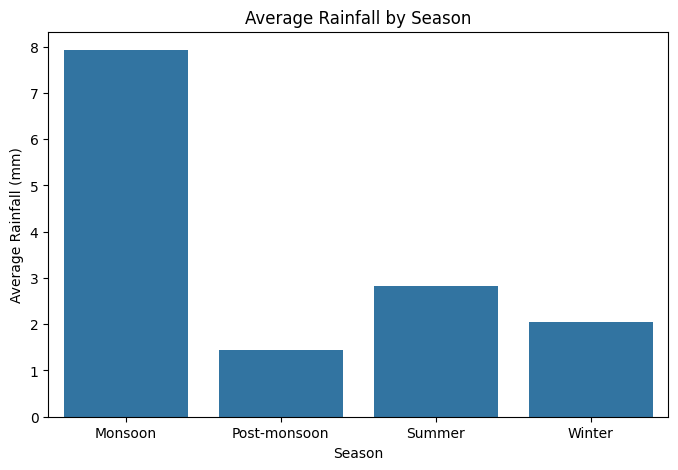

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_rainfall.index,
    y=season_rainfall.values
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")

plt.show()

## 12. Rainfall by Month

We analyze the average rainfall for each month to identify
monthly rainfall patterns in the dataset.

In [31]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

rainfall_data = df.dropna(subset=["rainfall"]).copy()

rainfall_data["rain_status"] = rainfall_data["rainfall"].apply(
    lambda x: "Rain" if x > 0 else "No Rain"
)

monthly_status = pd.crosstab(
    rainfall_data["month"],
    rainfall_data["rain_status"],
    normalize="index"
) * 100

monthly_status = monthly_status.reindex(month_order)

print(monthly_status)

rain_status    No Rain       Rain
month                            
January      70.713287  29.286713
February     70.032855  29.967145
March        64.562317  35.437683
April        67.064760  32.935240
May          60.071650  39.928350
June         52.568358  47.431642
July         23.116883  76.883117
August       27.049180  72.950820
September    37.888815  62.111185
October      74.040512  25.959488
November     84.077566  15.922434
December     82.594098  17.405902


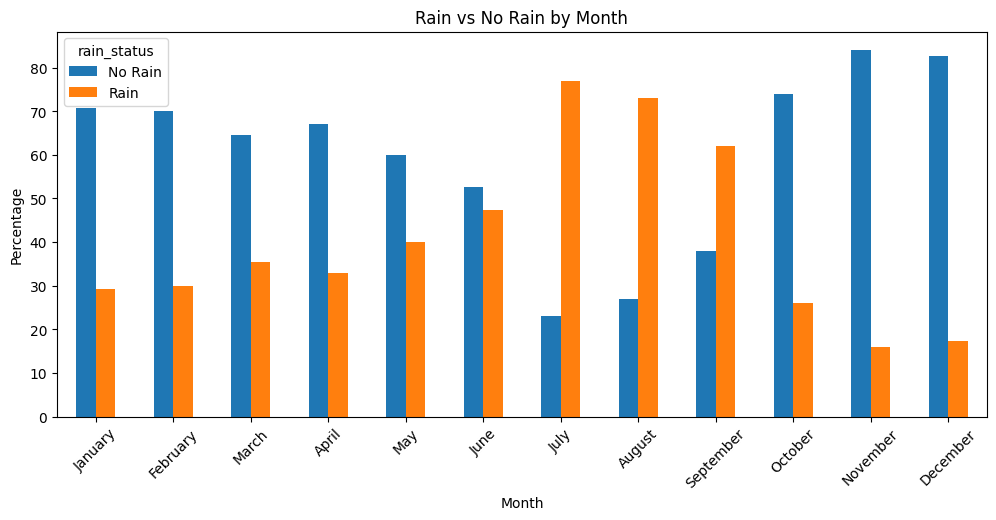

In [32]:
monthly_status.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Rain vs No Rain by Month")
plt.xlabel("Month")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()

In [33]:
rainfall_data = df.dropna(subset=["rainfall"]).copy()

rainfall_data["rain_status"] = rainfall_data["rainfall"].apply(
    lambda x: "Rain" if x > 0 else "No Rain"
)

print("Rows:", len(rainfall_data))

Rows: 74835


In [34]:
monthly_status = pd.crosstab(
    rainfall_data["month"],
    rainfall_data["rain_status"],
    normalize="index"
) * 100

print(monthly_status)

rain_status    No Rain       Rain
month                            
April        67.064760  32.935240
August       27.049180  72.950820
December     82.594098  17.405902
February     70.032855  29.967145
January      70.713287  29.286713
July         23.116883  76.883117
June         52.568358  47.431642
March        64.562317  35.437683
May          60.071650  39.928350
November     84.077566  15.922434
October      74.040512  25.959488
September    37.888815  62.111185


## 13. Data Cleaning

Based on the EDA, we will handle missing values carefully.

- Missing rainfall values cannot be used as the target.
- Numerical weather features will be handled separately.
- We will avoid blindly deleting all rows with missing values.
- Step 1 — Create a clean working dataset

First, remove only rows where rainfall is missing because rainfall is going to be our target.
Step 2 — Check remaining missing values
Step 3 — Fill numerical feature missing values

For the remaining numerical features, we'll use the median.


Why are we doing this?

We already removed rows where rainfall was missing because rainfall is our target.

For the weather features, instead of throwing away thousands of additional rows, we're replacing missing values with the median of that feature

In [35]:
df_clean = df.dropna(subset=["rainfall"]).copy()

print("Original rows:", len(df))
print("Rows after removing missing rainfall:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 100000
Rows after removing missing rainfall: 74835
Rows removed: 25165


In [36]:
df_clean.isnull().sum()

date_of_record        0
month                 0
season                0
station_name          0
state                 0
district              0
avg_temp              0
min_temp           1778
max_temp           2775
wind_speed        11377
air_pressure      11793
elevation             0
latitude              0
longitude             0
rainfall              0
dtype: int64

In [37]:
df_clean[
    ["min_temp", "max_temp", "wind_speed", "air_pressure"]
].median()

min_temp          15.7
max_temp          28.5
wind_speed         6.4
air_pressure    1011.4
dtype: float64

In [38]:
features_to_fill = [
    "min_temp",
    "max_temp",
    "wind_speed",
    "air_pressure"
]

for column in features_to_fill:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

In [39]:
df_clean.isnull().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64

## 14. Feature Engineering

Feature engineering transforms the cleaned data into useful features
for the machine learning model.

For this project, the target is whether rainfall occurs:
- Rainfall = 0 → No Rain
- Rainfall > 0 → Rain
Step 1 — Create the target column

Step 2 — Check the target percentage

In [40]:
df_clean["rain_status"] = df_clean["rainfall"].apply(
    lambda x: 1 if x > 0 else 0
)

In [41]:
df_clean["rain_status"].value_counts()

rain_status
0    43538
1    31297
Name: count, dtype: int64

## 15. Prepare Features and Target

- X contains the input features used by the machine learning model.
- y contains the target variable (`rain_status`).
- The original `rainfall` column is excluded because it was used to create the target.

In [42]:
features = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "wind_speed",
    "air_pressure",
    "elevation",
    "latitude",
    "longitude"
]

In [43]:
X = df_clean[features]
y = df_clean["rain_status"]

In [44]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (74835, 8)
y shape: (74835,)


## 16. Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to train the machine learning model.
- Testing data is used to evaluate the model on unseen data.
- 80% of the data will be used for training.
- 20% of the data will be used for testing.
Why stratify=y?

Our target has two classes:

0 → No Rain
1 → Rain

stratify=y makes sure the Rain/No Rain proportion remains approximately the same in both training and testing data.

For example:

Before split:
No Rain ≈ 58%
Rain    ≈ 42%

After split:
Training → ≈ 58% / 42%
Testing  → ≈ 58% / 42%

This is useful because our classes aren't perfectly balanced.

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (59868, 8)
X_test: (14967, 8)
y_train: (59868,)
y_test: (14967,)


## 17. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines
multiple decision trees to make a classification prediction.

For this project:
- 0 → No Rain
- 1 → Rain

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

hat these parameters mean
n_estimators=100 → build 100 decision trees
random_state=42 → makes the result reproducible
n_jobs=-1 → use all available CPU cores to speed up training

In [50]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
y_pred = rf_model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1]


## 18. Model Evaluation
## 18. Model Evaluation

The trained Random Forest model is evaluated on the unseen test data.

We will use:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

In [52]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7924099685975814


In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Rain", "Rain"]
))

              precision    recall  f1-score   support

     No Rain       0.81      0.84      0.83      8708
        Rain       0.77      0.72      0.74      6259

    accuracy                           0.79     14967
   macro avg       0.79      0.78      0.78     14967
weighted avg       0.79      0.79      0.79     14967



In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7348 1360]
 [1747 4512]]


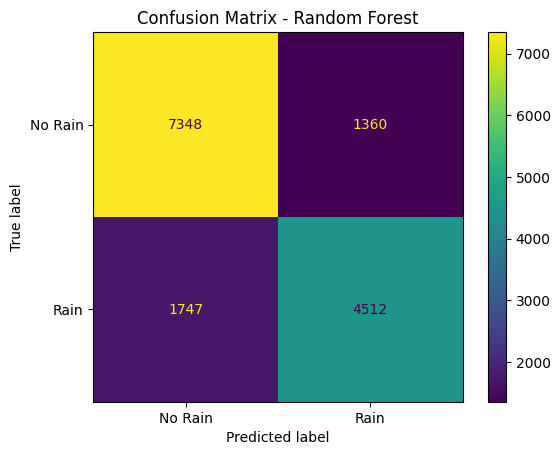

In [55]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain", "Rain"]
)

disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [56]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8708969052410188


## 19. Hyperparameter Tuning

The initial Random Forest model uses default/basic parameters.
Hyperparameter tuning is used to find better parameter combinations
and improve model performance.

In [57]:
from sklearn.model_selection import RandomizedSearchCV

In [58]:
param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [59]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [60]:
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [61]:
print("Best Parameters:")
print(rf_search.best_params_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}


In [62]:
print("Best Cross-Validation F1 Score:")
print(rf_search.best_score_)

Best Cross-Validation F1 Score:
0.7465266598869573


In [64]:
best_rf = rf_search.best_estimator_

print("Best tuned Random Forest model selected.")

Best tuned Random Forest model selected.


In [65]:
y_pred_tuned = best_rf.predict(X_test)

## 20. Tuned Model Evaluation

The tuned Random Forest model is evaluated on the unseen test dataset
using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [66]:
from sklearn.metrics import accuracy_score, classification_report

print("Tuned Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["No Rain", "Rain"]
    )
)

Tuned Random Forest Accuracy:
0.7994254025522817

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.82      0.84      0.83      8708
        Rain       0.77      0.74      0.75      6259

    accuracy                           0.80     14967
   macro avg       0.79      0.79      0.79     14967
weighted avg       0.80      0.80      0.80     14967



Confusion Matrix:
[[7350 1358]
 [1644 4615]]


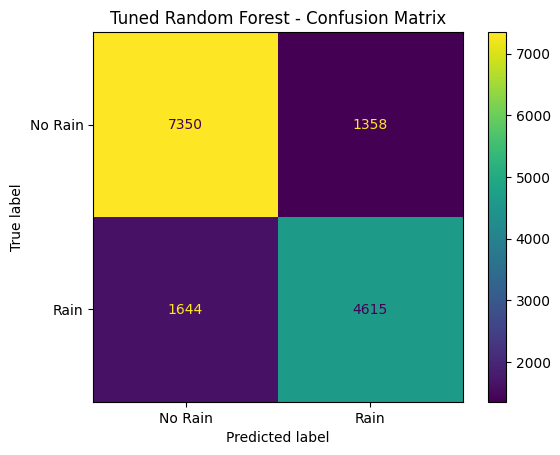

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Confusion Matrix:")
print(cm_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Rain", "Rain"]
)

disp.plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [68]:
from sklearn.metrics import roc_auc_score

y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Random Forest ROC-AUC:", roc_auc_tuned)

Tuned Random Forest ROC-AUC: 0.8794398170447143


In [69]:
original_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Original Random Forest Accuracy:", original_accuracy)
print("Tuned Random Forest Accuracy:", tuned_accuracy)

Original Random Forest Accuracy: 0.7924099685975814
Tuned Random Forest Accuracy: 0.7994254025522817


## 21. Feature Importance

Feature importance shows how much each input feature contributes
to the Random Forest's decisions.

This helps us understand which weather variables are most useful
for rainfall prediction.

Why this is useful

For your interview, you can explain:

"After training the Random Forest classifier, I analyzed feature importance to understand which meteorological variables contributed most to rainfall classification."

In [70]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

        Feature  Importance
2      max_temp    0.192225
1      min_temp    0.189186
0      avg_temp    0.158475
4  air_pressure    0.152935
3    wind_speed    0.101036
5     elevation    0.087265
6      latitude    0.072828
7     longitude    0.046050


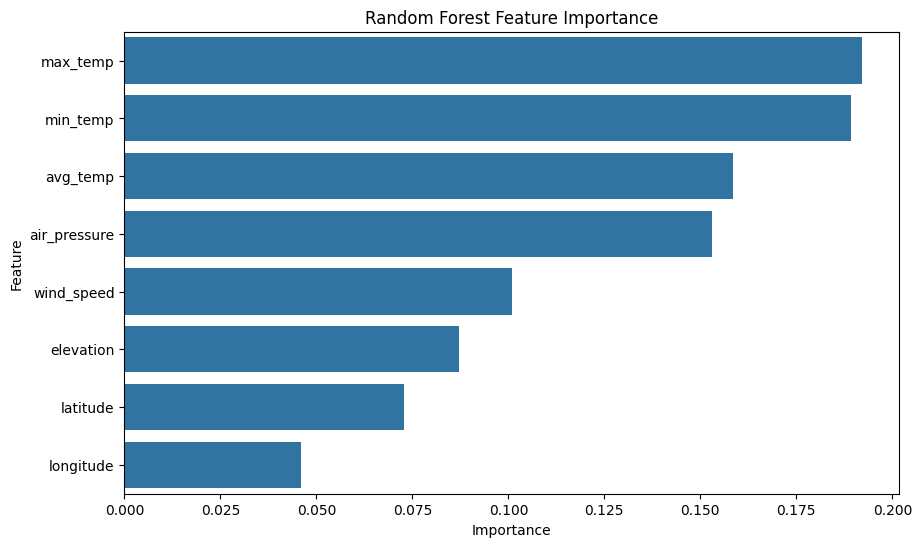

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 22. Model Comparison

Different machine learning algorithms are trained using the same
training and testing data.

The models will be compared using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Logistic Regression
Decision Tree
Random Forest
Gradient Boosting

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [73]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

gradient_model = GradientBoostingClassifier(
    random_state=42
)

In [74]:
logistic_model.fit(X_train, y_train)

decision_tree_model.fit(X_train, y_train)

gradient_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [75]:
y_pred_logistic = logistic_model.predict(X_test)

y_pred_tree = decision_tree_model.predict(X_test)

y_pred_gradient = gradient_model.predict(X_test)

In [77]:
def evaluate_model(name, model, y_pred):
    
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [78]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_model,
        y_pred_logistic
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        decision_tree_model,
        y_pred_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        best_rf,
        y_pred_tuned
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        gradient_model,
        y_pred_gradient
    )
)

comparison = pd.DataFrame(results)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.713904   0.685008  0.584758  0.630926  0.755077
1        Decision Tree  0.721320   0.665609  0.670395  0.667993  0.714175
2        Random Forest  0.799425   0.772644  0.737338  0.754578  0.879440
3    Gradient Boosting  0.767088   0.751132  0.662566  0.704075  0.841072


## 23. Final Model

The tuned Random Forest model is selected as the final model for
the current rainfall classification experiment.

The model predicts:
- 0 → No Rain
- 1 → Rain

## 23. Final Model
Save the model

First create the models folder from Jupyter's file browser if you haven't already:

Rainfall prediction/
│
├── 01_EDA_Rainfall_Prediction.ipynb
├── india_weather_rainfall_data.xlsx
└── models/

Then in a new Code cell:

In [79]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_rf, "models/rainfall_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [80]:
print(os.path.exists("models/rainfall_model.pkl"))

True


In [81]:
joblib.dump(features, "models/features.pkl")

print("Feature list saved successfully!")

Feature list saved successfully!


## 24. Load Saved Model and Make Prediction

In [82]:
import joblib

loaded_model = joblib.load("models/rainfall_model.pkl")
loaded_features = joblib.load("models/features.pkl")

print("Model loaded successfully!")
print("Features:", loaded_features)

Model loaded successfully!
Features: ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude']


In [83]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 0
Probability: [0.76272616 0.23727384]


## 25. Rainfall Prediction Function

This function accepts weather conditions as input and uses the
saved Random Forest model to predict whether rainfall will occur.

In [84]:
def predict_rainfall(
    avg_temp,
    min_temp,
    max_temp,
    wind_speed,
    air_pressure,
    elevation,
    latitude,
    longitude
):
    
    input_data = pd.DataFrame([[
        avg_temp,
        min_temp,
        max_temp,
        wind_speed,
        air_pressure,
        elevation,
        latitude,
        longitude
    ]], columns=loaded_features)
    
    prediction = loaded_model.predict(input_data)[0]
    probability = loaded_model.predict_proba(input_data)[0]
    
    if prediction == 1:
        result = "Rain"
    else:
        result = "No Rain"
    
    print("Prediction:", result)
    print("No Rain Probability:", round(probability[0] * 100, 2), "%")
    print("Rain Probability:", round(probability[1] * 100, 2), "%")

In [85]:
predict_rainfall(
    avg_temp=25,
    min_temp=20,
    max_temp=30,
    wind_speed=8,
    air_pressure=1008,
    elevation=200,
    latitude=28.6,
    longitude=77.2
)

Prediction: No Rain
No Rain Probability: 60.24 %
Rain Probability: 39.76 %
